# Transfer Learning using PyTorch

## Part 1 - Data Preprocessing

### Importing the libraries

In [1]:
import os
import kagglehub
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tqdm import tqdm
from tensorflow.keras import layers
from tensorflow.keras.models import Model
from sklearn.metrics import confusion_matrix

### Loading Intel image dataset from kaggle

In [2]:
path = kagglehub.dataset_download("puneet6060/intel-image-classification")
print(path)

Using Colab cache for faster access to the 'intel-image-classification' dataset.
/kaggle/input/intel-image-classification


In [3]:
train_dir = os.path.join(path, "seg_train", "seg_train")
test_dir = os.path.join(path, "seg_test", "seg_test")

In [4]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_dataset = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size = IMG_SIZE,
    batch_size = BATCH_SIZE,
    shuffle = True
)

test_dataset = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size = IMG_SIZE,
    batch_size = BATCH_SIZE,
    shuffle = False
)

Found 14034 files belonging to 6 classes.
Found 3000 files belonging to 6 classes.


## Defining Class Names

In [5]:
class_names = train_dataset.class_names
print(class_names)

['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


## Visualising the images

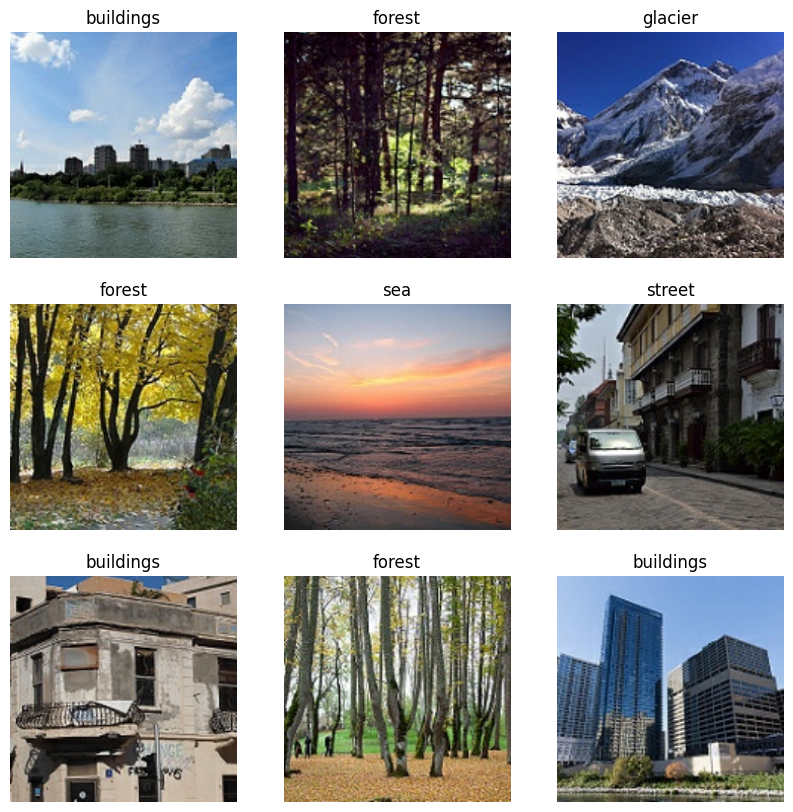

In [6]:
plt.figure(figsize = (10, 10))

for images, labels in train_dataset.take(1):

    for i in range(9):
        plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

plt.show()

## Normalizing the images

In [7]:
normalization = layers.Rescaling(1./255)

train_dataset = train_dataset.map(
    lambda x, y:(normalization(x), y)
)

test_dataset = test_dataset.map(
    lambda x, y:(normalization(x), y)
)

## Part 3 - Transfer Learning using PyTorch

### Importing the libraries

In [9]:
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets
from torchvision import models
from torchvision import transforms

from torch.utils.data import DataLoader

### Checking GPU availability

In [10]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print(device)

cuda


### Defining the image transformations

In [11]:
train_transform = transforms.Compose([

    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),

    transforms.Normalize(
        mean = [0.485, 0.456, 0.406],
        std = [0.229, 0.224, 0.225]
    )
])

In [12]:
test_transform = transforms.Compose([

    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean = [0.485, 0.456, 0.406],
        std = [0.229, 0.224, 0.225]
    )
])

### Creating the dataloaders

In [13]:
train_dataset_pt = datasets.ImageFolder(
    train_dir,
    transform = train_transform
)

In [14]:
test_dataset_pt = datasets.ImageFolder(
    test_dir,
    transform = test_transform
)

In [15]:
train_loader = DataLoader(
    train_dataset_pt,
    batch_size = 32,
    shuffle = True
)

In [16]:
test_loader = DataLoader(
    test_dataset_pt,
    batch_size = 32,
    shuffle = False
)

### Loading the pretrained ResNet18

In [17]:
weights = models.ResNet18_Weights.DEFAULT

model = models.resnet18(
    weights = weights
)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 207MB/s]


### Freezing the pretrained layers

In [18]:
for parameter in model.parameters():
    parameter.requires_grad = False

### Replacing the classifier

In [19]:
model.fc = nn.Linear(
    model.fc.in_features,
    len(train_dataset_pt.classes)
)

### Moving the model to GPU

In [20]:
model = model.to(device)

### Defining the loss function and optimizer

In [21]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.fc.parameters(),
    lr = 0.001
)

### Training the model (Feature Extraction)

In [22]:
print(type(train_loader.dataset))

<class 'torchvision.datasets.folder.ImageFolder'>


In [23]:
epochs = 5

for epoch in range(epochs):

    model.train()
    running_loss = 0
    correct = 0
    total = 0

    for images,labels in tqdm(train_loader):

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    print(f" Epoch {epoch+1}/{epochs}" f"  Loss: {running_loss:.4f}" f"  Accuracy: {100*correct/total:.2f}%")

100%|██████████| 439/439 [01:46<00:00,  4.14it/s]


Epoch 1/5  Loss: 215.1290  Accuracy: 83.70%


100%|██████████| 439/439 [00:55<00:00,  7.94it/s]


Epoch 2/5  Loss: 136.6547  Accuracy: 88.95%


100%|██████████| 439/439 [00:55<00:00,  7.94it/s]


Epoch 3/5  Loss: 125.5757  Accuracy: 90.04%


100%|██████████| 439/439 [00:55<00:00,  7.98it/s]


Epoch 4/5  Loss: 119.9826  Accuracy: 89.87%


100%|██████████| 439/439 [00:54<00:00,  8.05it/s]

Epoch 5/5  Loss: 117.9639  Accuracy: 90.42%


### Evaluating the model

In [24]:
model.eval()
correct = 0
total = 0
predictions = []
actual = []

with torch.no_grad():

    for images, labels in tqdm(test_loader):

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        predictions.extend(predicted.cpu().numpy())
        actual.extend(labels.cpu().numpy())

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(" Accuracy:", 100 * correct / total)

100%|██████████| 94/94 [00:21<00:00,  4.45it/s]

Accuracy: 90.76666666666667


### Unfreezing the last residual block

In [25]:
for parameter in model.layer4.parameters():
    parameter.requires_grad = True

### Creating a new optimizer

In [26]:
optimizer = optim.Adam(
    filter(
        lambda p: p.requires_grad,
        model.parameters()
    ),
    lr = 1e-5
)

### Fine-Tuning the model

In [27]:
epochs = 5

for epoch in range(epochs):

    model.train()
    running_loss = 0
    correct = 0
    total = 0

    for images, labels in tqdm(train_loader):

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    print(f" Epoch {epoch + 1}/{epochs}" f"  Loss: {running_loss:.4f}" f"  Accuracy: {100 * correct / total:.2f}%")

100%|██████████| 439/439 [00:56<00:00,  7.82it/s]


Epoch 1/5  Loss: 103.0951  Accuracy: 91.66%


100%|██████████| 439/439 [00:56<00:00,  7.81it/s]


Epoch 2/5  Loss: 81.7881  Accuracy: 93.42%


100%|██████████| 439/439 [00:56<00:00,  7.77it/s]


Epoch 3/5  Loss: 66.9301  Accuracy: 94.93%


100%|██████████| 439/439 [00:56<00:00,  7.76it/s]


Epoch 4/5  Loss: 54.1818  Accuracy: 95.85%


100%|██████████| 439/439 [00:56<00:00,  7.82it/s]

Epoch 5/5  Loss: 46.2187  Accuracy: 96.46%


### Evaluating after Fine-Tuning

In [28]:
model.eval()
correct = 0
total = 0
predictions = []
actual = []

with torch.no_grad():

    for images, labels in tqdm(test_loader):

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        predictions.extend(predicted.cpu().numpy())
        actual.extend(labels.cpu().numpy())

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

100%|██████████| 94/94 [00:11<00:00,  8.36it/s]

Accuracy: 93.4


In [35]:
print("Accuracy:", 100 * correct / total)

Accuracy: 93.4


### Making the confusion matrix

In [29]:
cm = confusion_matrix(actual, predictions)
print(cm)

[[403   0   0   1   2  31]
 [  0 472   0   1   0   1]
 [  1   4 476  59  13   0]
 [  1   0  37 474  12   1]
 [  0   1   3   2 504   0]
 [ 26   0   0   2   0 473]]


## Part 4 - Predicting New Images

### Loading a new image

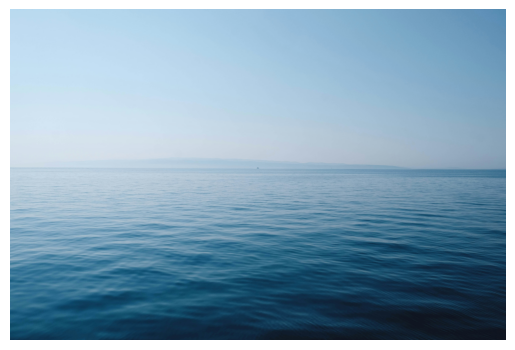

In [30]:
from PIL import Image

image_path = "image.jpg"
img = Image.open(image_path).convert("RGB")

plt.imshow(img)
plt.axis("off")
plt.show()

### Preprocessing the image

In [ ]:
img_tensor = test_transform(img)
img_tensor = img_tensor.unsqueeze(0).to(device)

model.eval()

### Predicting the image class

In [32]:
with torch.no_grad():
    outputs = model(img_tensor)
    _, predicted = torch.max(outputs, 1)

predicted_class = train_dataset_pt.classes[predicted.item()]
print("Predicted Class:", predicted_class)

Predicted Class: sea


## Part 5 - Saving the Model

### Saving the PyTorch model

In [33]:
torch.save(
    model.state_dict(), "resnet18_transfer_learning.pt")

### Loading the saved model

In [ ]:
model.load_state_dict(
    torch.load(
        "resnet18_transfer_learning.pt",
        map_location = device
    )
)

model.eval()